**Tyler Hilbert, Larry Purnell, Sandy Rath, Daniel Resnick | Seaborn In-Class Presentation | February 19, 2025**

This file serves as the **complete** view of our coding demonstration. Every section has comments (indicated via #) showing who is presenting, and a brief discussion of what is being discussed. Please refer to the **step-by-step** variant of this file for a way to break down the presentation into its base parts w/ detailed instructions of what is happening in the code.

Intro Part:
- Go over what Seaborn is (Sandy)
- Why it is different than Matplotlib (Daniel)
- Use cases for Seaborn (Larry)
- Downloading Seaborn and the terminal thing (Tyler)

In [4]:
#Tyler
import seaborn as sns #brings Seaborn into the Jupyter file to make use of the functions within
import pandas as pd #brings pandas into the Jupyter file to make use of the functions within
from matplotlib import pyplot as plt

In [2]:
#Tyler
spotify = pd.read_csv("spotify-2023.csv",encoding='latin1') #reads the CSV file and assigns it to a variable. The file is encoded, so needs encoding=to recognize the file
spotify.head() #runs the variable to make sure it works, plus shows the first five observations

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


In [3]:
#Tyler
spotify.keys() #pulls the keys for the spotify dataset. This will help identify potential data points for future use

Index(['track_name', 'artist(s)_name', 'artist_count', 'released_year',
       'released_month', 'released_day', 'in_spotify_playlists',
       'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts',
       'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm',
       'key', 'mode', 'danceability_%', 'valence_%', 'energy_%',
       'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%'],
      dtype='object')

[]

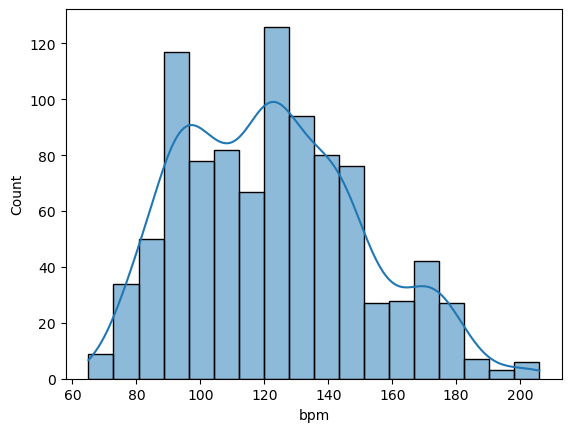

In [8]:
#Daniel
hist = sns.histplot(data=spotify,x="bpm",kde="true") #Using a histogram visualization to show BPM along the X-axis - the kde function shows the distribution across BPM
hist.plot()
# plt.show()

In [9]:
#Daniel
releasemonthgroup = spotify.groupby("released_month").count()["track_name"] #This is to start cleaning up the data for a future visualization. This counts all instances of each month in the dataset
releasemonthgroup #running the variable to make sure it actually works and caught them

released_month
1     134
2      61
3      86
4      66
5     128
6      86
7      62
8      46
9      56
10     73
11     80
12     75
Name: track_name, dtype: int64

In [10]:
#Daniel
releasemonthvalues = releasemonthgroup.values #provides a usable array of the release month values
releasemonthvalues #running to make sure it worked

array([134,  61,  86,  66, 128,  86,  62,  46,  56,  73,  80,  75])

In [27]:
#Daniel
releasemonthindex = releasemonthgroup.index #provides an index of the release month column headers
releasemonthindex #running to make sure it worked
releasemonth_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul","Aug", "Sep", "Oct", "Nov", "Dec"]

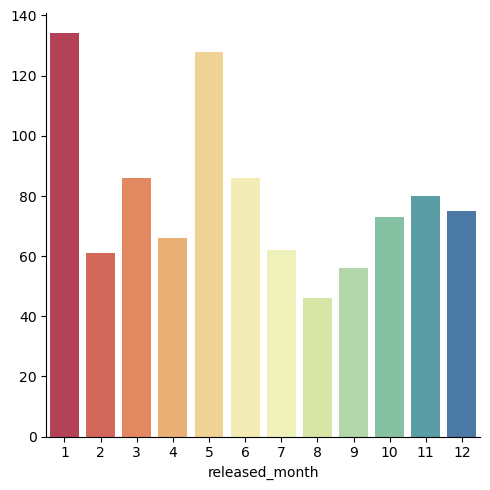

In [28]:
#Larry
cat = sns.catplot(x=releasemonthindex, y=releasemonthvalues, kind="bar", hue = releasemonth_names, palette="Spectral", legend=False) #Turns the releasemonth data into a Bar chart. Also shows an example of specifying what kind of chart is made, the palette function, and hiding the legend
plt.show()

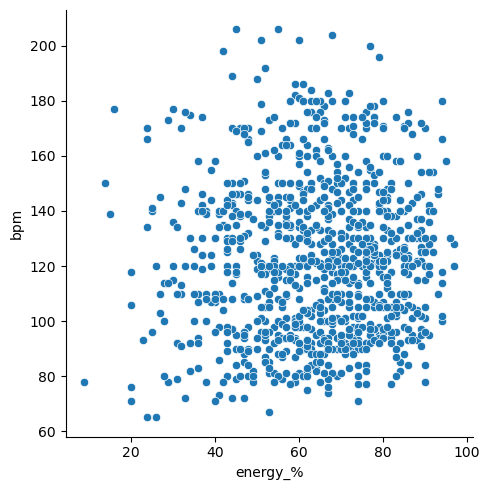

In [10]:
#Larry
sns.relplot(data=spotify, x="energy_%", y="bpm") #Now moving from catplot to relplot, this is just showing how you can plug values in and it'll spit out a table

In [11]:
#Larry
modelist = spotify.groupby("mode").count()["track_name"] #Doing a quick check to see how many different items are under the Mode column
modelist #Doing the actual check of the mode and items. See there are only two, so a great choice for a binary item

mode
Major    550
Minor    403
Name: track_name, dtype: int64

In [30]:
spotify['month_cat'] = spotify['released_month'].astype('category')
spotify['month_cat'] = spotify['month_cat'].cat.rename_categories(releasemonth_names)

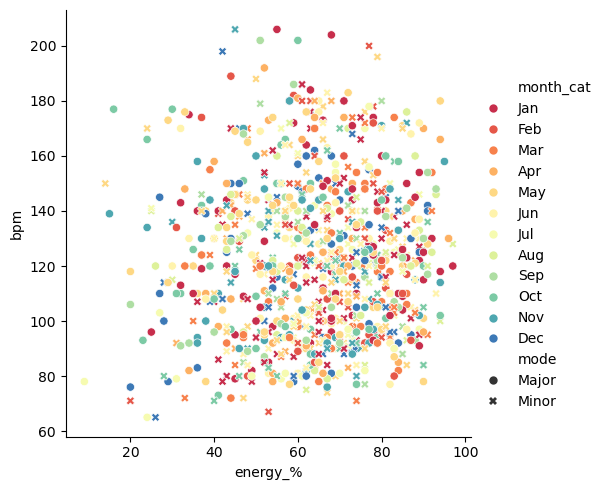

In [31]:
#Larry
sns.relplot(data=spotify, x="energy_%", y="bpm",style="mode",hue="month_cat", palette="Spectral") #Revisiting the plot from earlier, now we are adding style and hue to customize the look of it (getting at the different ways to showcase it)

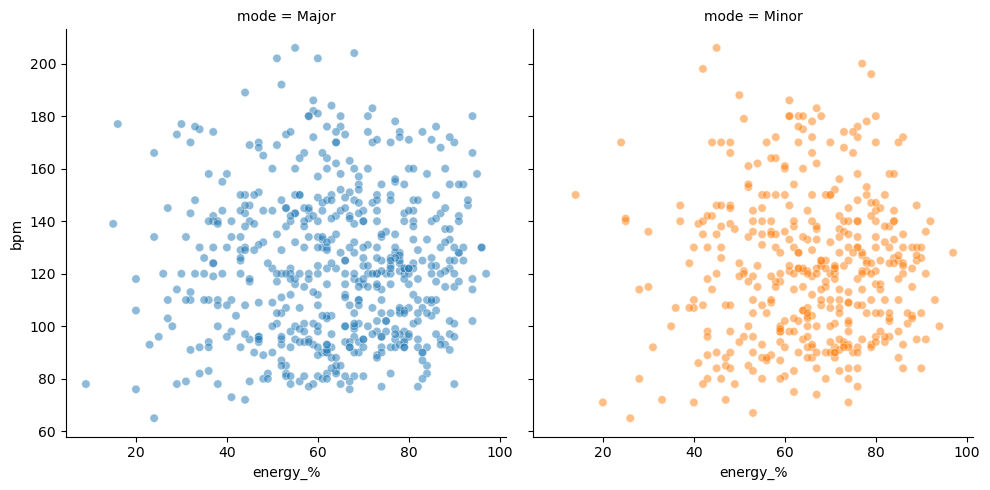

In [32]:
#Sandy
sns.relplot(data=spotify, x="energy_%", y="bpm",col="mode",hue="mode",alpha=.5,legend=False) #An alternative way of doing things - instead of flooding it with aesthetic stuff, making multiple tables to show when there are two options. Also hiding the legend and adding alpha

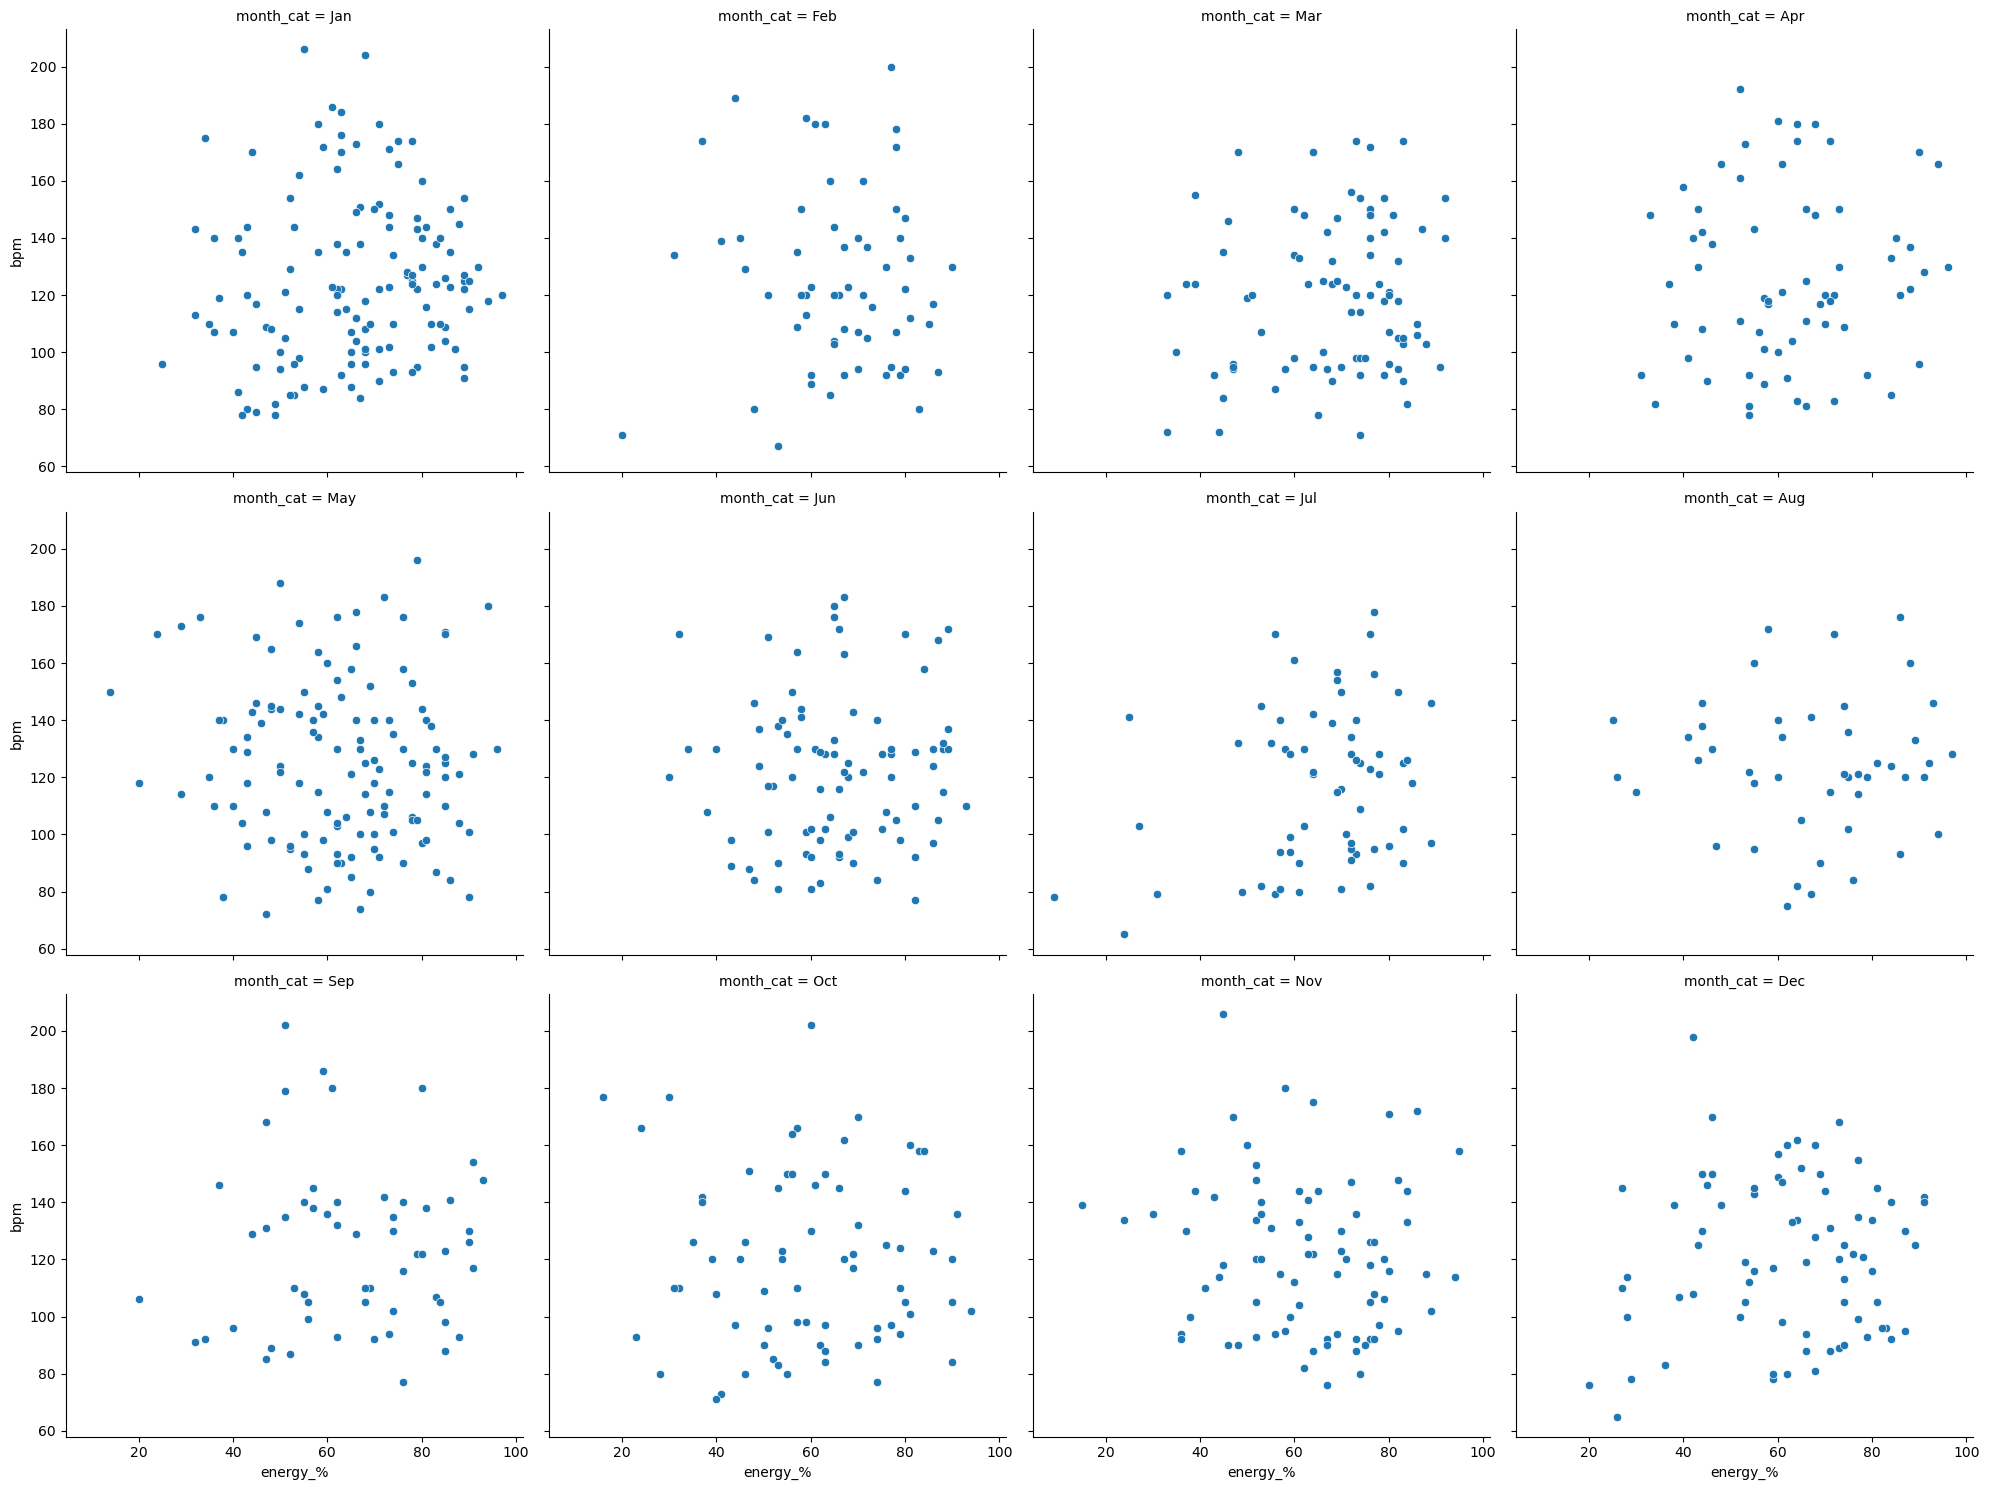

In [35]:
#Sandy
sns.relplot(data=spotify, x="energy_%", y="bpm",col="month_cat",col_wrap=4) #Last big push - revisiting the wrap function - what happens when you have a lot of items you want to sort by, you can view the different data